# Align before Fuse: Vision and Language Representation Learning with Momentum Distillation

**Authors:** Junnan Li, Ramprasaath R. Selvaraju, Akhilesh D. Gotmare, Shafiq Joty, Caiming Xiong, Steven C.H. Hoi
**Venue:** NeurIPS 2021
**Affiliation:** Salesforce Research

# https://arxiv.org/pdf/2107.07651

---

## Abstract

ALBEF (ALign BEfore Fuse) is a vision-language pre-training (VLP) framework that introduces
an image-text contrastive (ITC) loss to align unimodal image and text representations prior to
cross-modal fusion. It further proposes Momentum Distillation (MoD), a self-training method
leveraging pseudo-targets from a momentum model to handle noisy web supervision. ALBEF
achieves state-of-the-art performance across multiple vision-language benchmarks without
requiring object detectors or bounding box annotations, and with substantially faster inference
than prior methods.

---

## Problems

1. **Unaligned feature spaces:** Existing VLP methods (e.g., LXMERT, UNITER, OSCAR) fuse
   image region features and word token embeddings directly via multimodal encoders, despite
   these representations residing in separate, unaligned spaces — hindering effective cross-modal
   learning.

2. **Object detector dependency:** Most methods rely on pre-trained object detectors requiring
   bounding box annotations for pre-training and high-resolution images (e.g., 600×1000) during
   inference, creating a significant computational bottleneck.

3. **Noisy web supervision:** Web-collected image-text pairs are inherently noisy — texts may
   describe content not present in images, and hard negatives for contrastive or MLM objectives
   may actually be valid positives. Standard one-hot supervision penalizes all non-ground-truth
   outputs equally, degrading generalization.

---

## Proposed Solutions

1. **Image-Text Contrastive (ITC) Loss:** Aligns unimodal image and text representations before
   multimodal fusion, enabling easier cross-modal attention learning and providing a basis for
   contrastive hard negative mining.

2. **Contrastive Hard Negative Mining:** Uses ITC similarity scores to sample semantically similar
   but fine-grained-distinct negative pairs for Image-Text Matching (ITM), improving the
   informativeness of training samples at zero additional computational cost.

3. **Momentum Distillation (MoD):** A self-training method using a momentum model (exponential
   moving average of the base model) to generate soft pseudo-targets for both ITC and MLM
   objectives, replacing hard one-hot supervision with KL-divergence-based soft targets:

$$\mathcal{L}^{\text{mod}}_{\text{itc}} = (1 - \alpha)\mathcal{L}_{\text{itc}} + \frac{\alpha}{2} \mathbb{E}_{(I,T)} \left[ \text{KL}(q^{i2t}(I) \| p^{i2t}(I)) + \text{KL}(q^{t2i}(T) \| p^{t2i}(T)) \right]$$

$$\mathcal{L}^{\text{mod}}_{\text{mlm}} = (1 - \alpha)\mathcal{L}_{\text{mlm}} + \alpha \mathbb{E}_{(I,\hat{T})} \text{KL}(q^{\text{msk}}(I, \hat{T}) \| p^{\text{msk}}(I, \hat{T}))$$

---

## Purpose

To develop a detector-free, scalable VLP framework that produces both strong unimodal and
multimodal representations, unifying contrastive and fusion-based paradigms for robust
performance across retrieval and reasoning tasks, while addressing noisy supervision from
web-scale data.

---

## Methodology

### Model Architecture

| Component | Architecture | Initialization |
|---|---|---|
| Image Encoder | ViT-B/16 (12 layers) | ImageNet-1k pre-trained |
| Text Encoder | Transformer (6 layers) | BERT_base (first 6 layers) |
| Multimodal Encoder | Transformer with cross-attention (6 layers) | BERT_base (last 6 layers) |

Image features are fused into the multimodal encoder via cross-attention at each layer.
The model is detector-free, operating on raw image patches at 256×256 (pre-training) and
384×384 (fine-tuning).

### Pre-training Objectives

The full pre-training loss is:

$$\mathcal{L} = \mathcal{L}_{\text{itc}} + \mathcal{L}_{\text{mlm}} + \mathcal{L}_{\text{itm}}$$

- **ITC:** Symmetric softmax-normalized contrastive loss over image-to-text and text-to-image
  similarities using momentum queues of size 65,536.
- **MLM:** Cross-entropy loss predicting masked tokens (15% masking rate) using image and
  contextual text.
- **ITM:** Binary classification on matched/unmatched image-text pairs using hard negatives
  mined via ITC similarity.

### Momentum Model

- Parameters updated via exponential moving average: $\theta' \leftarrow m\theta' + (1-m)\theta$,
  with momentum $m = 0.995$.
- Generates soft pseudo-targets $q^{i2t}$, $q^{t2i}$, $q^{\text{msk}}$ used as KL-divergence
  supervision targets.
- Distillation weight $\alpha = 0.4$, linearly ramped up over the first epoch.

### Pre-training Datasets

| Dataset | Images | Pairs |
|---|---|---|
| COCO + VG + CC + SBU (4M) | 4.0M | 5.1M |
| + Conceptual 12M (14M) | 14.1M | ~15M |

### Downstream Tasks and Fine-tuning

- **Image-Text Retrieval:** ITC + ITM with two-stage inference (ITC filtering → ITM re-ranking).
- **VQA:** Auto-regressive 6-layer transformer decoder generating answers from multimodal
  embeddings.
- **NLVR2:** Replicated multimodal blocks per image with shared cross-attention weights;
  additional text-assignment (TA) pre-training step.
- **Visual Entailment (SNLI-VE):** Three-way MLP classifier on [CLS] representation.
- **Visual Grounding (RefCOCO+):** Weakly supervised; Grad-CAM heatmaps on cross-attention
  maps for localization.

---

## Results

### Image-Text Retrieval (Fine-tuned, Flickr30K 1K test)

| Method | Pre-train Images | TR R@1 | IR R@1 |
|---|---|---|---|
| UNITER | 4M | 87.3 | 75.6 |
| ALIGN | 1.2B | 95.3 | 84.9 |
| ALBEF | 4M | 94.3 | 82.8 |
| ALBEF | 14M | 95.9 | 85.6 |

### Zero-Shot Retrieval (Flickr30K 1K test)

| Method | Pre-train Images | TR R@1 | IR R@1 |
|---|---|---|---|
| CLIP | 400M | 88.0 | 68.7 |
| ALIGN | 1.2B | 88.6 | 75.7 |
| ALBEF | 4M | 90.5 | 76.8 |
| ALBEF | 14M | 94.1 | 82.8 |

### VQA, NLVR2, and Visual Entailment

| Method | VQA test-std | NLVR2 test-P | SNLI-VE test |
|---|---|---|---|
| VILLA | 73.67 | 79.30 | 79.03 |
| ALBEF (4M) | 74.70 | 80.50 | 80.30 |
| ALBEF (14M) | 76.04 | 83.14 | 80.91 |

ALBEF achieves absolute improvements of **+2.37%** on VQA, **+3.84%** on NLVR2, and
**+1.88%** on SNLI-VE over the prior SOTA (VILLA), while being more than **10x faster**
on NLVR2 inference.

### Ablation (Flickr30K, 4M pre-training)

| Configuration | TR (avg) | IR (avg) |
|---|---|---|
| MLM + ITM (baseline) | 93.96 | 88.55 |
| + ITC | 96.55 | 91.69 |
| + Hard negatives | 97.01 | 92.16 |
| + ITC_MoD | 97.33 | 92.43 |
| + MLM_MoD (Full) | 97.47 | 92.58 |
| + MoD Downstream | 97.83 | 92.65 |

Each proposed component contributes incrementally and consistently across all tasks.

---

## Conclusions

ALBEF establishes that aligning unimodal representations via contrastive learning before
cross-modal fusion is a principled and effective strategy for vision-language pre-training.
The theoretical analysis frames ITC, MLM, and MoD as complementary mutual information
maximization objectives over different views of an image-text pair. Momentum Distillation
provides a robust mechanism for learning from noisy web data by replacing brittle one-hot
targets with soft pseudo-labels from a temporal ensemble. ALBEF outperforms methods
pre-trained on orders of magnitude more data while remaining detector-free and inference-efficient.
The framework scales effectively with data volume and generalizes across retrieval, reasoning,
entailment, and grounding tasks, making it a strong and principled foundation for vision-language
representation learning.

# Mathematical and Statistical Content: ALBEF

---

## 1. Similarity Function (Dot Product Score)

$$s(I, T) = g_v(v_{\text{cls}})^\top g'_w(w'_{\text{cls}}), \quad s(T, I) = g_w(w_{\text{cls}})^\top g'_v(v'_{\text{cls}})$$

**What it means:** A dot product between normalized image and text embeddings measures how
well an image-text pair matches. Higher dot product = more similar. The primed quantities
($g'_v$, $g'_w$) come from the momentum model (a slowly-updated copy of the main model),
while unprimed ones come from the base model. Two directions are computed: image-queries-text
and text-queries-image.

---

## 2. Softmax-Normalized Similarity Distribution

$$p_m^{i2t}(I) = \frac{\exp(s(I, T_m)/\tau)}{\sum_{m=1}^{M} \exp(s(I, T_m)/\tau)}, \quad
p_m^{t2i}(T) = \frac{\exp(s(T, I_m)/\tau)}{\sum_{m=1}^{M} \exp(s(T, I_m)/\tau)}$$

**What it means:** These are softmax distributions over a queue of $M$ candidates. For a
given image $I$, $p_m^{i2t}(I)$ gives the probability that text $T_m$ is the correct match.
The temperature $\tau$ is a learnable scalar — small $\tau$ sharpens the distribution (more
confident), large $\tau$ flattens it. This converts raw similarity scores into a proper
probability distribution suitable for cross-entropy training.

---

## 3. Image-Text Contrastive (ITC) Loss

$$\mathcal{L}_{\text{itc}} = \frac{1}{2} \mathbb{E}_{(I,T) \sim \mathcal{D}}
\left[ H(y^{i2t}(I),\ p^{i2t}(I)) + H(y^{t2i}(T),\ p^{t2i}(T)) \right]$$

**What it means:** A symmetric cross-entropy loss. $H(y, p)$ penalizes the model when its
predicted distribution $p$ disagrees with the ground-truth one-hot label $y$ (where only the
true match has probability 1, all others 0). The symmetry means the model is simultaneously
trained to: (1) find the right text for each image, and (2) find the right image for each
text. This is the standard InfoNCE-style contrastive objective adapted to image-text pairs.

---

## 4. Masked Language Modeling (MLM) Loss

$$\mathcal{L}_{\text{mlm}} = \mathbb{E}_{(I, \hat{T}) \sim \mathcal{D}}\ H(y^{\text{msk}},\ p^{\text{msk}}(I, \hat{T}))$$

**What it means:** 15% of input text tokens are randomly masked. The model must predict the
correct original word at each masked position, using both the image and surrounding text as
context. $y^{\text{msk}}$ is a one-hot vector over the full vocabulary (1 for the correct
word, 0 for all others). The cross-entropy $H$ penalizes wrong predictions. This forces the
multimodal encoder to understand how image content relates to textual semantics.

---

## 5. Image-Text Matching (ITM) Loss

$$\mathcal{L}_{\text{itm}} = \mathbb{E}_{(I,T) \sim \mathcal{D}}\ H(y^{\text{itm}},\ p^{\text{itm}}(I, T))$$

**What it means:** A binary classification loss. The model predicts whether an image-text
pair is matched (1) or not matched (0). $y^{\text{itm}}$ is a 2-dimensional one-hot vector.
Hard negatives — pairs that are semantically close but not the true match — are selected
using the ITC similarity scores, making this objective more discriminative without added
computational cost.

---

## 6. Full Pre-training Objective

$$\mathcal{L} = \mathcal{L}_{\text{itc}} + \mathcal{L}_{\text{mlm}} + \mathcal{L}_{\text{itm}}$$

**What it means:** The total training loss is the unweighted sum of all three objectives.
ITC aligns unimodal representations; MLM trains the multimodal encoder for contextual
understanding; ITM trains the model for fine-grained image-text matching. Each loss
targets a different level of cross-modal understanding.

---

## 7. Momentum Model Update Rule

$$\theta'_{\text{mom}} \leftarrow m \cdot \theta'_{\text{mom}} + (1 - m) \cdot \theta_{\text{base}}$$

**What it means:** The momentum model's parameters are not trained by gradient descent
directly. Instead, they are a slow exponential moving average (EMA) of the base model's
parameters, with momentum coefficient $m = 0.995$. This means the momentum model changes
very slowly and provides a stable, temporally-smoothed teacher — effectively an ensemble
of recent model states — whose predictions are more reliable than the noisy base model's
at any single step.

---

## 8. Momentum Distillation — ITC Soft Pseudo-Targets

$$q_m^{i2t}(I) = \frac{\exp(s'(I, T_m)/\tau)}{\sum_{m=1}^{M} \exp(s'(I, T_m)/\tau)}$$

where $s'(I, T) = g'_v(v'_{\text{cls}})^\top g'_w(w'_{\text{cls}})$.

**What it means:** Instead of hard one-hot labels (only the annotated pair = 1), the
momentum model produces a soft probability distribution over all $M$ candidates. Texts
that are semantically close to the image get higher soft probabilities, even if they are
not the ground-truth annotation. This captures the reality that web data often has multiple
valid matches for a single image.

---

## 9. Momentum Distillation — ITC Loss (ITCMoD)

$$\mathcal{L}^{\text{mod}}_{\text{itc}} = (1 - \alpha)\,\mathcal{L}_{\text{itc}}
+ \frac{\alpha}{2}\, \mathbb{E}_{(I,T)} \left[
\text{KL}(q^{i2t}(I) \| p^{i2t}(I)) + \text{KL}(q^{t2i}(T) \| p^{t2i}(T))
\right]$$

**What it means:** A weighted combination of the original hard-label contrastive loss and a
KL-divergence term that pulls the base model's predictions toward the momentum model's
soft pseudo-targets. $\alpha = 0.4$ controls the balance. The KL divergence
$\text{KL}(q \| p) = \sum_m q_m \log(q_m / p_m)$ is minimized when $p$ matches $q$, so
the base model learns to mimic the momentum model's broader, softer judgments about which
texts are semantically relevant — not just the one ground-truth annotation.

---

## 10. Momentum Distillation — MLM Loss (MLMMoD)

$$\mathcal{L}^{\text{mod}}_{\text{mlm}} = (1 - \alpha)\,\mathcal{L}_{\text{mlm}}
+ \alpha\, \mathbb{E}_{(I, \hat{T})} \,
\text{KL}(q^{\text{msk}}(I, \hat{T}) \| p^{\text{msk}}(I, \hat{T}))$$

**What it means:** The same distillation principle applied to masked language modeling.
The momentum model generates a soft distribution $q^{\text{msk}}$ over the full vocabulary
for each masked position. For example, if the ground-truth masked word is "standing", the
momentum model might also assign probability mass to "walking" or "running" — words that
are equally valid given the image. The base model is trained to match this richer
distribution rather than a single one-hot answer.

---

## 11. InfoNCE Loss (Theoretical Connection)

$$\mathcal{L}_{\text{NCE}} = -\mathbb{E}_{p(a,b)} \left[
\log \frac{\exp(s(a,b))}{\sum_{\hat{b} \in \hat{\mathcal{B}}} \exp(s(a, \hat{b}))}
\right]$$

**What it means:** InfoNCE is an established lower bound on Mutual Information (MI) between
two random variables $a$ and $b$. Minimizing InfoNCE is equivalent to maximizing a lower
bound on $\text{MI}(a, b)$. The paper shows that the ITC loss (Equation 3) is a symmetric
version of InfoNCE, where $a = I$ (image) and $b = T$ (text) are treated as two "views"
of the same semantic content. This provides a theoretical grounding for why ITC helps
representation learning.

---

## 12. MLM as Mutual Information Maximization

$$\mathcal{L}_{\text{mlm}} = -\mathbb{E}_{p(I,\hat{T})} \left[
\log \frac{\exp(\psi(y^{\text{msk}})^\top f(I, \hat{T}))}
{\sum_{y \in \mathcal{V}} \exp(\psi(y)^\top f(I, \hat{T}))}
\right]$$

**What it means:** Rewriting MLM in InfoNCE form shows it also maximizes a lower bound on
MI — specifically between a masked word token and its context (image + surrounding text).
Here $\psi(y)$ maps vocabulary tokens to vectors, and $f(I, \hat{T})$ is the multimodal
encoder's hidden state at the masked position. The "two views" in this case are: (1) the
masked word, and (2) the full image-plus-masked-text context.

---

## 13. Momentum Distillation as MI Maximization over Expanded Views

$$-\sum_m q_m^{i2t}(I) \log p_m^{i2t}(I) =
-\sum_m \frac{\exp(s'(I, T_m)/\tau)}{\sum_{m'} \exp(s'(I, T_{m'})/\tau)}
\log \frac{\exp(s(I, T_m)/\tau)}{\sum_{m'} \exp(s(I, T_{m'})/\tau)}$$

**What it means:** Minimizing the KL term in ITCMoD is equivalent to maximizing
$\text{MI}(I, T_m)$ weighted by how semantically similar $T_m$ is to $I$ under the
momentum model. Texts that are highly similar to the image contribute more to the
objective. This shows MoD is theoretically equivalent to performing data augmentation —
generating new semantically valid views of each image-text pair — grounding the method
in the mutual information maximization framework.

---

## 14. Exponential Moving Average (EMA) — Statistical Role

The momentum model is a temporal ensemble:

$$\theta'_t = m \cdot \theta'_{t-1} + (1-m) \cdot \theta_t$$

**What it means:** With $m = 0.995$, the momentum model at step $t$ is approximately a
weighted average of the base model over the last $\sim 200$ steps (since
$(0.995)^{200} \approx 0.37$). This statistical smoothing reduces variance in the
pseudo-targets, making them more stable and reliable as a teacher signal than the
instantaneous base model predictions, which fluctuate during early training.

---

## 15. Hard Negative Sampling Strategy

For each image $I$ in a mini-batch, a negative text $T^-$ is sampled with probability
proportional to the ITC similarity:

$$P(T^- = T_j \mid I) \propto p_j^{i2t}(I), \quad T_j \neq T^+$$

**What it means:** Rather than sampling random negatives (easy negatives that the model
quickly learns to reject), this strategy preferentially selects texts that score highly
against the image under ITC — semantically close but incorrect matches. This makes ITM
training significantly more challenging and informative, accelerating learning of
fine-grained visual-semantic distinctions at zero additional compute cost.

---

## Summary Table

| Mathematical Component | Type | Role in ALBEF |
|---|---|---|
| Dot product similarity $s(I,T)$ | Scoring function | Measures image-text alignment |
| Softmax over queue | Probability distribution | Converts scores to match probabilities |
| ITC Loss $\mathcal{L}_{\text{itc}}$ | Cross-entropy | Aligns unimodal representations |
| MLM Loss $\mathcal{L}_{\text{mlm}}$ | Cross-entropy | Trains multimodal contextual understanding |
| ITM Loss $\mathcal{L}_{\text{itm}}$ | Cross-entropy | Fine-grained image-text matching |
| EMA update | Exponential smoothing | Produces stable momentum teacher |
| Soft pseudo-targets $q^{i2t}$, $q^{\text{msk}}$ | Soft distributions | Replace hard labels over noisy data |
| KL divergence | Distributional distance | Distills knowledge from momentum model |
| ITCMoD, MLMMoD | Weighted loss combination | Noise-robust training objectives |
| InfoNCE lower bound | MI lower bound | Theoretical justification for ITC and MLM |
| Hard negative sampling | Importance sampling | Selects informative ITM negatives |
| Temperature $\tau$ | Learnable scalar | Controls distribution sharpness |

# ALBEF: Problem–Gap–Solution Analysis

---

## Structured Review Table

| # | Problem / Research Gap | Limitation in Prior Work | Proposed Solution in ALBEF |
|---|---|---|---|
| 1 | **Unaligned unimodal feature spaces before fusion** | Methods such as LXMERT, UNITER, and OSCAR directly feed image region features and word token embeddings into a shared multimodal encoder without prior alignment. Because the two modalities reside in separate representation spaces, the encoder must simultaneously align and fuse them, making cross-modal attention learning harder and less effective. | An **Image-Text Contrastive (ITC) loss** is applied to the unimodal encoders before fusion. ITC trains image and text representations to occupy a shared, semantically aligned low-dimensional space (256-d), so the subsequent multimodal encoder performs fusion on already-compatible representations. |
| 2 | **Dependency on pre-trained object detectors** | Most VLP methods (LXMERT, UNITER, OSCAR, VILLA) extract visual features using region-based object detectors that require expensive bounding box annotations during pre-training and high-resolution images (e.g., 600×1000) during inference. This creates a major computational bottleneck and annotation cost, while tying model quality to the detector's coverage of visual concepts. | ALBEF adopts a **detector-free image encoder** (ViT-B/16) that processes raw image patches. No bounding box annotations are required. Pre-training uses 256×256 crops; fine-tuning uses 384×384 images — far lower resolution than detector-based methods — while achieving superior performance and inference speed. |
| 3 | **Noisy and weakly correlated web image-text pairs** | Web-collected datasets (Conceptual Captions, SBU Captions) are inherently noisy: captions may describe entities absent from the image and vice versa. Standard one-hot supervision for ITC and MLM penalizes all non-ground-truth outputs equally, even when they are semantically valid alternatives. This causes the model to overfit to noisy annotations and degrades generalization. | **Momentum Distillation (MoD)** generates soft pseudo-targets from a momentum model (an exponential moving average of the base model). These soft targets assign probability mass to semantically valid but unannotated alternatives. The base model is trained to minimize KL divergence between its predictions and the pseudo-targets, rather than fitting hard one-hot labels, making learning robust to annotation noise. |
| 4 | **Uninformative negative samples in ITM training** | Image-Text Matching (ITM) typically trains on randomly sampled negatives that are semantically distant from the anchor — making the task trivially easy. The model fails to learn fine-grained visual-semantic distinctions because it is never exposed to hard, near-miss negative examples during ITM training. | **Contrastive hard negative mining** uses the ITC similarity scores to select in-batch negatives that are semantically similar to the anchor but not the true match. Negatives are sampled proportionally to ITC similarity, ensuring the ITM objective always trains on maximally informative pairs at zero additional computational overhead. |
| 5 | **Weak unimodal representations in fusion-centric models** | Methods focusing on multimodal fusion (e.g., UNITER, OSCAR) produce strong joint representations but relatively weak standalone unimodal encoders, limiting performance on tasks requiring efficient unimodal retrieval (e.g., image-text retrieval at scale). Conversely, purely contrastive models (CLIP, ALIGN) produce strong unimodal encoders but lack the capacity for complex multimodal reasoning tasks such as VQA and NLVR2. | ALBEF **unifies both paradigms** by combining ITC (strengthening unimodal encoders) with MLM and ITM (strengthening multimodal fusion). This produces models that are simultaneously competitive on retrieval tasks (matching CLIP and ALIGN trained on 400M–1.2B pairs) and on reasoning tasks (surpassing all prior methods on VQA, NLVR2, and SNLI-VE). |
| 6 | **Slow inference speed due to exhaustive cross-modal scoring** | Methods such as UNITER, OSCAR, and VILLA compute ITM scores for all possible image-text pairs during retrieval inference, making inference time scale quadratically with dataset size. This is prohibitive for large-scale retrieval benchmarks and real-world deployment. | ALBEF introduces a **two-stage inference pipeline**: (1) ITC similarity scores efficiently rank all candidates using lightweight unimodal dot products; (2) only the top-$k$ candidates (a small subset) are re-ranked using the more expensive ITM score. Since $k$ can be very small, inference is orders of magnitude faster — more than 10× faster than VILLA on NLVR2 — with negligible performance loss. |
| 7 | **Lack of theoretical grounding for multi-task VLP objectives** | Most VLP methods combine ITC, MLM, and ITM empirically without a unified theoretical justification for why these objectives are complementary or how they collectively contribute to better representations. This limits principled understanding and extension of the framework. | ALBEF provides a **Mutual Information (MI) maximization framework** unifying all three objectives. ITC maximizes MI between image and text views; MLM maximizes MI between a masked word and its image-text context; MoD extends this by generating additional semantically valid views via the momentum model's soft distributions, interpreting the full framework as multi-view representation learning. |
| 8 | **Inability to reason over multiple images** | Standard VLP multimodal encoders are designed to process a single image paired with text, making them inapplicable to tasks requiring joint reasoning over two images simultaneously, such as NLVR2 (which requires predicting whether a caption describes an image pair). Adapting single-image encoders to this setting is non-trivial. | For NLVR2, ALBEF **replicates each multimodal encoder block** into two parallel transformer blocks — one per image — with shared cross-attention projection weights. An additional **text-assignment (TA) pre-training step** (1 epoch) prepares the model to assign text to one of two images or neither, enabling accurate image-pair reasoning without re-designing the full architecture. |

---

## Summary of Thematic Clusters

| Theme | Problems Addressed | Core ALBEF Innovation |
|---|---|---|
| Representation Alignment | Gaps 1, 5 | ITC loss aligning unimodal spaces before fusion |
| Scalable Architecture | Gap 2 | Detector-free ViT-B/16 image encoder |
| Noise Robustness | Gap 3 | Momentum Distillation with soft pseudo-targets |
| Training Efficiency | Gap 4 | Contrastive hard negative mining for ITM |
| Inference Efficiency | Gap 6 | Two-stage ITC-filter + ITM-rerank inference |
| Theoretical Foundations | Gap 7 | MI maximization unifying ITC, MLM, and MoD |
| Multi-image Reasoning | Gap 8 | Replicated multimodal blocks with TA pre-training |

In [18]:
# =============================================================================
# ALBEF: Align Before Fuse — Simplified Educational PyTorch Implementation
# CORRECTED VERSION — fixes TypeError: _forward_unimplemented()
# =============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision.transforms as transforms

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

from datasets import load_dataset
from PIL import Image

import copy
import io
from io import BytesIO
from IPython.display import display, Image as IPImage

from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: Configuration
# ─────────────────────────────────────────────────────────────────────────────

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

NUM_EPOCHS  = 5
BATCH_SIZE  = 64
LR          = 1e-4
WEIGHT_DECAY= 0.02
EMBED_DIM   = 128
MOMENTUM    = 0.995
ALPHA       = 0.4
QUEUE_SIZE  = 256
TEMP        = 0.07
NUM_CLASSES = 10

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

Using device: cuda


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2: Dataset — HuggingFace CIFAR-10
# ─────────────────────────────────────────────────────────────────────────────

print("Loading CIFAR-10 from HuggingFace...")
ds = load_dataset("uoft-cs/cifar10")

class HuggingFaceCIFAR10(Dataset):
    """
    Wraps a HuggingFace split into a PyTorch Dataset.
    Reads PIL images from 'img', labels from 'label'.
    """
    def __init__(self, hf_split, transform=None):
        self.data      = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        image  = sample["img"]
        if not isinstance(image, Image.Image):
            image = Image.fromarray(image)
        image = image.convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, sample["label"]

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

full_train = HuggingFaceCIFAR10(ds["train"], transform=train_transform)
full_test  = HuggingFaceCIFAR10(ds["test"],  transform=test_transform)

train_dataset = Subset(full_train, range(2000))
test_dataset  = Subset(full_test,  range(400))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2)

# Sanity check
print(f"\nDataset Sanity Check:")
print(f"  Training samples : {len(train_dataset)}")
print(f"  Test samples     : {len(test_dataset)}")
imgs, lbls = next(iter(train_loader))
print(f"  Batch image shape: {imgs.shape}")
print(f"  Label range      : [{lbls.min().item()}, {lbls.max().item()}]")
print(f"  First 8 classes  : {[CLASS_NAMES[l.item()] for l in lbls[:8]]}")

Loading CIFAR-10 from HuggingFace...

Dataset Sanity Check:
  Training samples : 2000
  Test samples     : 400
  Batch image shape: torch.Size([64, 3, 64, 64])
  Label range      : [0, 9]
  First 8 classes  : ['horse', 'airplane', 'automobile', 'bird', 'ship', 'automobile', 'automobile', 'bird']


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: Model Architecture
# ─────────────────────────────────────────────────────────────────────────────
# ROOT CAUSE FIX EXPLANATION:
# The original error arose because CrossAttention (an nn.Module subclass)
# did not explicitly define forward(), so PyTorch registered it with the
# stub _forward_unimplemented(). When model(images, labels, return_loss=True)
# was called, PyTorch's __call__ machinery sometimes routed keyword arguments
# to child modules instead of the top-level forward().
#
# FIXES APPLIED:
#   1. Every nn.Module subclass now has an explicit, unambiguous forward()
#      method with a clear signature. No submodule forward() accepts
#      **kwargs or extra keyword arguments.
#   2. ALBEFModel no longer accepts return_loss as a forward() argument.
#      Instead, loss computation is always performed inside forward() and
#      returned as a dict alongside logits. This removes the keyword argument
#      that was causing the dispatch error entirely.
#   3. The train/eval loop calls model(images, labels) — no extra kwargs.
# ─────────────────────────────────────────────────────────────────────────────

class ImageEncoder(nn.Module):
    """
    Lightweight CNN image encoder.
    Replaces ViT-B/16 from the original ALBEF for CIFAR-10 scale.
    Produces a single visual [CLS] embedding vector per image.
    """
    def __init__(self, embed_dim=EMBED_DIM):
        super(ImageEncoder, self).__init__()
        self.conv_blocks = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 64 → 32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 32 → 16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 16 → 8
        )
        self.fc   = nn.Linear(128 * 8 * 8, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)

    # FIX: explicit forward with clear, minimal signature — no **kwargs
    def forward(self, x):
        # x: (B, 3, 64, 64)
        h = self.conv_blocks(x)             # (B, 128, 8, 8)
        h = h.view(h.size(0), -1)           # (B, 8192)
        h = self.fc(h)                      # (B, embed_dim)
        return self.norm(h)


class TextEncoder(nn.Module):
    """
    Learned class-name embedding encoder.
    Replaces BERT-base (first 6 layers) from the original ALBEF.
    Maps integer class IDs to dense semantic embedding vectors.
    """
    def __init__(self, num_classes=NUM_CLASSES, embed_dim=EMBED_DIM):
        super(TextEncoder, self).__init__()
        self.embedding = nn.Embedding(num_classes, embed_dim)
        self.fc        = nn.Linear(embed_dim, embed_dim)
        self.norm      = nn.LayerNorm(embed_dim)

    # FIX: explicit forward — accepts only class_ids, no extra kwargs
    def forward(self, class_ids):
        # class_ids: (B,) integer tensor
        h = self.embedding(class_ids)       # (B, embed_dim)
        h = self.fc(h)
        return self.norm(h)


class CrossAttentionLayer(nn.Module):
    """
    Single cross-attention layer.
    Query comes from one modality; Key/Value from the other.
    Implements the cross-modal attention in ALBEF's multimodal encoder.

    NOTE on the original bug:
    This class was previously named CrossAttention. The critical fix is
    ensuring forward() is explicitly defined here so PyTorch never falls
    back to _forward_unimplemented() for this module.
    """
    def __init__(self, embed_dim=EMBED_DIM):
        super(CrossAttentionLayer, self).__init__()
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out    = nn.Linear(embed_dim, embed_dim)
        self.scale  = embed_dim ** -0.5

    # FIX: explicit forward — (query, key_value) only, no **kwargs
    def forward(self, query, key_value):
        # query    : (B, embed_dim)
        # key_value: (B, embed_dim)
        Q    = self.q_proj(query)
        K    = self.k_proj(key_value)
        V    = self.v_proj(key_value)
        attn = torch.sigmoid((Q * K).sum(dim=-1, keepdim=True) * self.scale)
        out  = attn * V
        return self.out(out)                # (B, embed_dim)


class MultimodalEncoder(nn.Module):
    """
    Cross-modal fusion encoder.
    Replaces BERT-base (last 6 layers) + cross-attention from original ALBEF.
    Fuses already-aligned image and text features.
    """
    def __init__(self, embed_dim=EMBED_DIM):
        super(MultimodalEncoder, self).__init__()
        # Image attends to text; text attends to image
        self.img2txt = CrossAttentionLayer(embed_dim)
        self.txt2img = CrossAttentionLayer(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim),
        )
        self.norm = nn.LayerNorm(embed_dim)

    # FIX: explicit forward — (img_feat, txt_feat) only, no **kwargs
    def forward(self, img_feat, txt_feat):
        img_cross = self.img2txt(img_feat, txt_feat)    # (B, embed_dim)
        txt_cross = self.txt2img(txt_feat, img_feat)    # (B, embed_dim)
        fused     = self.ffn(torch.cat([img_cross, txt_cross], dim=-1))
        return self.norm(img_feat + fused)              # (B, embed_dim)


class ALBEFModel(nn.Module):
    """
    Full ALBEF-inspired model for CIFAR-10 classification.

    Three training objectives (mirroring the paper):
      ITC — Image-Text Contrastive loss (aligns unimodal representations)
      ITM — Image-Text Matching loss    (fine-grained cross-modal matching)
      CLS — Classification loss         (downstream task; replaces MLM here)

    Momentum Distillation (MoD) is applied to the ITC objective.

    FIX: forward() signature is (self, images, class_ids) with NO extra
    keyword arguments. Loss computation always happens inside forward()
    and is always returned. This eliminates the return_loss dispatch error.
    """
    def __init__(self, num_classes=NUM_CLASSES, embed_dim=EMBED_DIM,
                 queue_size=QUEUE_SIZE, momentum=MOMENTUM, alpha=ALPHA):
        super(ALBEFModel, self).__init__()

        self.momentum   = momentum
        self.alpha      = alpha
        self.queue_size = queue_size

        # ── Unimodal Encoders ─────────────────────────────────────────────
        self.image_encoder = ImageEncoder(embed_dim)
        self.text_encoder  = TextEncoder(num_classes, embed_dim)

        # ── Multimodal Fusion Encoder ─────────────────────────────────────
        self.multimodal_encoder = MultimodalEncoder(embed_dim)

        # ── ITC Projection Heads (to 64-d normalized space) ───────────────
        itc_dim = 64
        self.img_proj = nn.Linear(embed_dim, itc_dim)
        self.txt_proj = nn.Linear(embed_dim, itc_dim)

        # Learnable temperature τ (initialised to 0.07, per paper §3.2)
        self.temp = nn.Parameter(torch.ones([]) * TEMP)

        # ── ITM Head — binary match / no-match classifier ─────────────────
        self.itm_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.ReLU(),
            nn.Linear(embed_dim // 2, 2),
        )

        # ── Classification Head — downstream prediction ───────────────────
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(embed_dim // 2, num_classes),
        )

        # ── Momentum (EMA) Encoders — not updated by backprop ─────────────
        self.mom_image_encoder = copy.deepcopy(self.image_encoder)
        self.mom_text_encoder  = copy.deepcopy(self.text_encoder)
        self.mom_img_proj      = copy.deepcopy(self.img_proj)
        self.mom_txt_proj      = copy.deepcopy(self.txt_proj)

        for p in self.mom_image_encoder.parameters(): p.requires_grad = False
        for p in self.mom_text_encoder.parameters():  p.requires_grad = False
        for p in self.mom_img_proj.parameters():      p.requires_grad = False
        for p in self.mom_txt_proj.parameters():      p.requires_grad = False

        # ── Contrastive Queue (MoCo-style) ────────────────────────────────
        self.register_buffer("image_queue",
            F.normalize(torch.randn(itc_dim, queue_size), dim=0))
        self.register_buffer("text_queue",
            F.normalize(torch.randn(itc_dim, queue_size), dim=0))
        self.register_buffer("queue_ptr",
            torch.zeros(1, dtype=torch.long))

    @torch.no_grad()
    def _momentum_update(self):
        """
        EMA update: θ'_mom ← m·θ'_mom + (1−m)·θ_base
        Keeps the momentum model as a smooth temporal ensemble.
        """
        pairs = [
            (self.image_encoder, self.mom_image_encoder),
            (self.text_encoder,  self.mom_text_encoder),
            (self.img_proj,      self.mom_img_proj),
            (self.txt_proj,      self.mom_txt_proj),
        ]
        for base, mom in pairs:
            for pb, pm in zip(base.parameters(), mom.parameters()):
                pm.data = pm.data * self.momentum + pb.data * (1.0 - self.momentum)

    @torch.no_grad()
    def _dequeue_and_enqueue(self, img_feat_m, txt_feat_m):
        """
        Circular buffer update for the contrastive queue.
        Replaces oldest entries with current momentum features.
        """
        B   = img_feat_m.shape[0]
        ptr = int(self.queue_ptr)
        if ptr + B > self.queue_size:
            B            = self.queue_size - ptr
            img_feat_m   = img_feat_m[:B]
            txt_feat_m   = txt_feat_m[:B]
        self.image_queue[:, ptr:ptr + B] = img_feat_m.T
        self.text_queue[:, ptr:ptr + B]  = txt_feat_m.T
        self.queue_ptr[0] = (ptr + B) % self.queue_size

    # FIX: forward() takes only (images, class_ids) — NO return_loss kwarg.
    # Loss is always computed and returned. This is the key fix for the
    # TypeError: _forward_unimplemented() got an unexpected keyword argument.
    def forward(self, images, class_ids):
        """
        Full ALBEF forward pass.

        Args:
            images    : (B, 3, 64, 64)
            class_ids : (B,) integer class label tensor

        Returns:
            logits : (B, num_classes)
            losses : dict with keys 'total', 'itc', 'itm', 'cls'
        """
        B = images.size(0)

        # ── 1. Unimodal Encoding (no fusion yet) ──────────────────────────
        img_feat = self.image_encoder(images)     # (B, embed_dim)
        txt_feat = self.text_encoder(class_ids)   # (B, embed_dim)

        # ── 2. ITC Projections — normalized shared space ──────────────────
        img_proj = F.normalize(self.img_proj(img_feat), dim=-1)   # (B, 64)
        txt_proj = F.normalize(self.txt_proj(txt_feat), dim=-1)   # (B, 64)

        # ── 3. Momentum Model Forward (no gradient) ───────────────────────
        with torch.no_grad():
            self._momentum_update()
            img_feat_m = self.mom_image_encoder(images)
            txt_feat_m = self.mom_text_encoder(class_ids)
            img_proj_m = F.normalize(self.mom_img_proj(img_feat_m), dim=-1)
            txt_proj_m = F.normalize(self.mom_txt_proj(txt_feat_m), dim=-1)

            # Extended negatives: current batch + queue
            all_img_m = torch.cat(
                [img_proj_m.T, self.image_queue.clone().detach()], dim=1
            )  # (64, B + Q)
            all_txt_m = torch.cat(
                [txt_proj_m.T, self.text_queue.clone().detach()], dim=1
            )  # (64, B + Q)

        # ── 4. ITC Hard Loss (Eq. 2 in paper) ────────────────────────────
        # Softmax similarity over queue+batch negatives
        sim_i2t = img_proj @ all_txt_m / self.temp   # (B, B+Q)
        sim_t2i = txt_proj @ all_img_m / self.temp   # (B, B+Q)
        targets  = torch.arange(B, device=DEVICE)

        loss_itc_hard = (
            F.cross_entropy(sim_i2t[:, :B], targets) +
            F.cross_entropy(sim_t2i[:, :B], targets)
        ) / 2.0

        # ── 5. Momentum Distillation — Soft ITC (Eq. 6 in paper) ─────────
        with torch.no_grad():
            sim_i2t_m = img_proj_m @ all_txt_m / self.temp
            sim_t2i_m = txt_proj_m @ all_img_m / self.temp
            soft_i2t  = F.softmax(sim_i2t_m[:, :B], dim=-1).detach()
            soft_t2i  = F.softmax(sim_t2i_m[:, :B], dim=-1).detach()

        loss_mod_itc = (
            F.kl_div(F.log_softmax(sim_i2t[:, :B], dim=-1),
                     soft_i2t, reduction="batchmean") +
            F.kl_div(F.log_softmax(sim_t2i[:, :B], dim=-1),
                     soft_t2i, reduction="batchmean")
        ) / 2.0

        # Combined ITC with MoD weighting
        loss_itc = (1 - self.alpha) * loss_itc_hard + self.alpha * loss_mod_itc

        # Update queue with current momentum features
        self._dequeue_and_enqueue(img_proj_m, txt_proj_m)

        # ── 6. Multimodal Fusion via Cross-Attention ──────────────────────
        fused = self.multimodal_encoder(img_feat, txt_feat)  # (B, embed_dim)

        # ── 7. ITM Loss (Eq. 4 in paper) ─────────────────────────────────
        # Positive pairs: true (image, class_id) — label 1
        itm_pos = self.itm_head(fused)                       # (B, 2)

        # Hard negatives: shuffled class_ids create mismatched pairs — label 0
        neg_ids      = class_ids[torch.randperm(B, device=DEVICE)]
        neg_txt_feat = self.text_encoder(neg_ids)
        fused_neg    = self.multimodal_encoder(img_feat.detach(), neg_txt_feat)
        itm_neg      = self.itm_head(fused_neg)              # (B, 2)

        pos_lbl = torch.ones(B,  dtype=torch.long, device=DEVICE)
        neg_lbl = torch.zeros(B, dtype=torch.long, device=DEVICE)
        loss_itm = (
            F.cross_entropy(itm_pos, pos_lbl) +
            F.cross_entropy(itm_neg, neg_lbl)
        ) / 2.0

        # ── 8. Classification Loss ────────────────────────────────────────
        logits  = self.classifier(fused)                     # (B, num_classes)
        loss_cls = F.cross_entropy(logits, class_ids)

        # ── 9. Total Loss (L = L_itc + L_itm + L_cls) ────────────────────
        loss_total = loss_itc + loss_itm + loss_cls

        losses = {
            "total": loss_total,
            "itc"  : loss_itc,
            "itm"  : loss_itm,
            "cls"  : loss_cls,
        }
        return logits, losses

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4: Instantiate Model
# ─────────────────────────────────────────────────────────────────────────────

model = ALBEFModel().to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel Summary:")
print(f"  Total parameters    : {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")


Model Summary:
  Total parameters    : 2,701,325
  Trainable parameters: 1,524,109


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5: Optimizer and Scheduler
# ─────────────────────────────────────────────────────────────────────────────

optimizer = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR, weight_decay=WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6: Training and Evaluation Functions
# ─────────────────────────────────────────────────────────────────────────────

def train_one_epoch(model, loader, optimizer):
    """
    One full training pass over the data loader.
    FIX: calls model(images, labels) — no return_loss keyword argument.
    """
    model.train()
    running = {"total": 0.0, "itc": 0.0, "itm": 0.0, "cls": 0.0}
    correct, total = 0, 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        # FIX: no return_loss kwarg — forward() always returns losses
        logits, losses = model(images, labels)

        losses["total"].backward()
        nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad],
            max_norm=1.0
        )
        optimizer.step()

        n = images.size(0)
        for k in running:
            running[k] += losses[k].item() * n

        correct += (logits.argmax(dim=-1) == labels).sum().item()
        total   += n

    avg = {k: v / total for k, v in running.items()}
    return avg, correct / total


@torch.no_grad()
def evaluate(model, loader):
    """
    Full evaluation pass — no gradients.
    FIX: calls model(images, labels) — no return_loss keyword argument.
    Returns losses, accuracy, per-class accuracy, predictions,
    true labels, and confidence scores.
    """
    model.eval()
    running = {"total": 0.0, "itc": 0.0, "itm": 0.0, "cls": 0.0}
    correct, total = 0, 0

    all_preds, all_labels, all_confs = [], [], []
    class_correct = np.zeros(NUM_CLASSES)
    class_total   = np.zeros(NUM_CLASSES)

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # FIX: no return_loss kwarg
        logits, losses = model(images, labels)

        n = images.size(0)
        for k in running:
            running[k] += losses[k].item() * n

        probs       = F.softmax(logits, dim=-1)
        confs, preds = probs.max(dim=-1)

        correct += (preds == labels).sum().item()
        total   += n

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_confs.extend(confs.cpu().numpy())

        for c in range(NUM_CLASSES):
            mask = (labels == c)
            class_correct[c] += (preds[mask] == labels[mask]).sum().item()
            class_total[c]   += mask.sum().item()

    avg = {k: v / total for k, v in running.items()}
    per_class_acc = np.divide(
        class_correct, class_total,
        out=np.zeros_like(class_correct),
        where=class_total > 0
    )
    return (avg, correct / total, per_class_acc,
            np.array(all_preds), np.array(all_labels), np.array(all_confs))

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7: Training Loop — 5 Epochs
# ─────────────────────────────────────────────────────────────────────────────

history = {
    "train_loss_total": [], "train_loss_itc": [],
    "train_loss_itm":   [], "train_loss_cls": [],
    "train_acc":        [],
    "val_loss_total":   [], "val_loss_itc":   [],
    "val_loss_itm":     [], "val_loss_cls":   [],
    "val_acc":          [],
    "val_per_class_acc": [],
}

best_val_acc  = 0.0
best_epoch    = 0
final_preds   = None
final_labels  = None
final_confs   = None

print("\n" + "="*60)
print(" ALBEF Training on CIFAR-10 (HuggingFace) — 5 Epochs")
print("="*60)

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)

    (val_loss, val_acc, val_per_class_acc,
     preds, labels, confs) = evaluate(model, test_loader)

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch

    final_preds  = preds
    final_labels = labels
    final_confs  = confs

    for k in ["total", "itc", "itm", "cls"]:
        history[f"train_loss_{k}"].append(train_loss[k])
        history[f"val_loss_{k}"].append(val_loss[k])
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_per_class_acc"].append(val_per_class_acc.copy())

    print(f"\nEpoch [{epoch}/{NUM_EPOCHS}]")
    print(f"  Train — Loss: {train_loss['total']:.4f} "
          f"| ITC: {train_loss['itc']:.4f} "
          f"| ITM: {train_loss['itm']:.4f} "
          f"| CLS: {train_loss['cls']:.4f} "
          f"| Acc: {train_acc:.4f}")
    print(f"  Val   — Loss: {val_loss['total']:.4f} "
          f"| ITC: {val_loss['itc']:.4f} "
          f"| ITM: {val_loss['itm']:.4f} "
          f"| CLS: {val_loss['cls']:.4f} "
          f"| Acc: {val_acc:.4f}")

print("\n" + "="*60)
print(f" Training Complete | Best Val Acc: {best_val_acc:.4f} @ Epoch {best_epoch}")
print("="*60)


 ALBEF Training on CIFAR-10 (HuggingFace) — 5 Epochs

Epoch [1/5]
  Train — Loss: 5.8798 | ITC: 2.6604 | ITM: 1.0221 | CLS: 2.1973 | Acc: 0.2345
  Val   — Loss: 5.5329 | ITC: 2.3855 | ITM: 1.1235 | CLS: 2.0238 | Acc: 0.4075

Epoch [2/5]
  Train — Loss: 4.8674 | ITC: 2.2657 | ITM: 0.9111 | CLS: 1.6905 | Acc: 0.6240
  Val   — Loss: 4.2854 | ITC: 2.2748 | ITM: 0.7682 | CLS: 1.2424 | Acc: 0.8950

Epoch [3/5]
  Train — Loss: 3.8178 | ITC: 2.1457 | ITM: 0.7370 | CLS: 0.9351 | Acc: 0.9715
  Val   — Loss: 3.6310 | ITC: 2.1938 | ITM: 0.7098 | CLS: 0.7274 | Acc: 1.0000

Epoch [4/5]
  Train — Loss: 3.4300 | ITC: 2.0763 | ITM: 0.7021 | CLS: 0.6516 | Acc: 0.9980
  Val   — Loss: 3.4495 | ITC: 2.1507 | ITM: 0.6981 | CLS: 0.6007 | Acc: 1.0000

Epoch [5/5]
  Train — Loss: 3.2930 | ITC: 2.0203 | ITM: 0.6949 | CLS: 0.5778 | Acc: 1.0000
  Val   — Loss: 3.3895 | ITC: 2.1183 | ITM: 0.6978 | CLS: 0.5734 | Acc: 1.0000

 Training Complete | Best Val Acc: 1.0000 @ Epoch 3


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8: Post-Training Analysis
# ─────────────────────────────────────────────────────────────────────────────

cm              = confusion_matrix(final_labels, final_preds)
cm_norm         = cm.astype(float) / cm.sum(axis=1, keepdims=True)
final_per_class = history["val_per_class_acc"][-1]
sorted_idx      = np.argsort(final_per_class)[::-1]
top_classes     = [CLASS_NAMES[i] for i in sorted_idx[:3]]
bot_classes     = [CLASS_NAMES[i] for i in sorted_idx[-3:]]
correct_mask    = (final_preds == final_labels)
mean_conf_corr  = final_confs[correct_mask].mean()  if correct_mask.any()  else 0.0
mean_conf_incorr= final_confs[~correct_mask].mean() if (~correct_mask).any() else 0.0
epochs_range    = list(range(1, NUM_EPOCHS + 1))
per_class_heatmap = np.array(history["val_per_class_acc"])  # (5, 10)

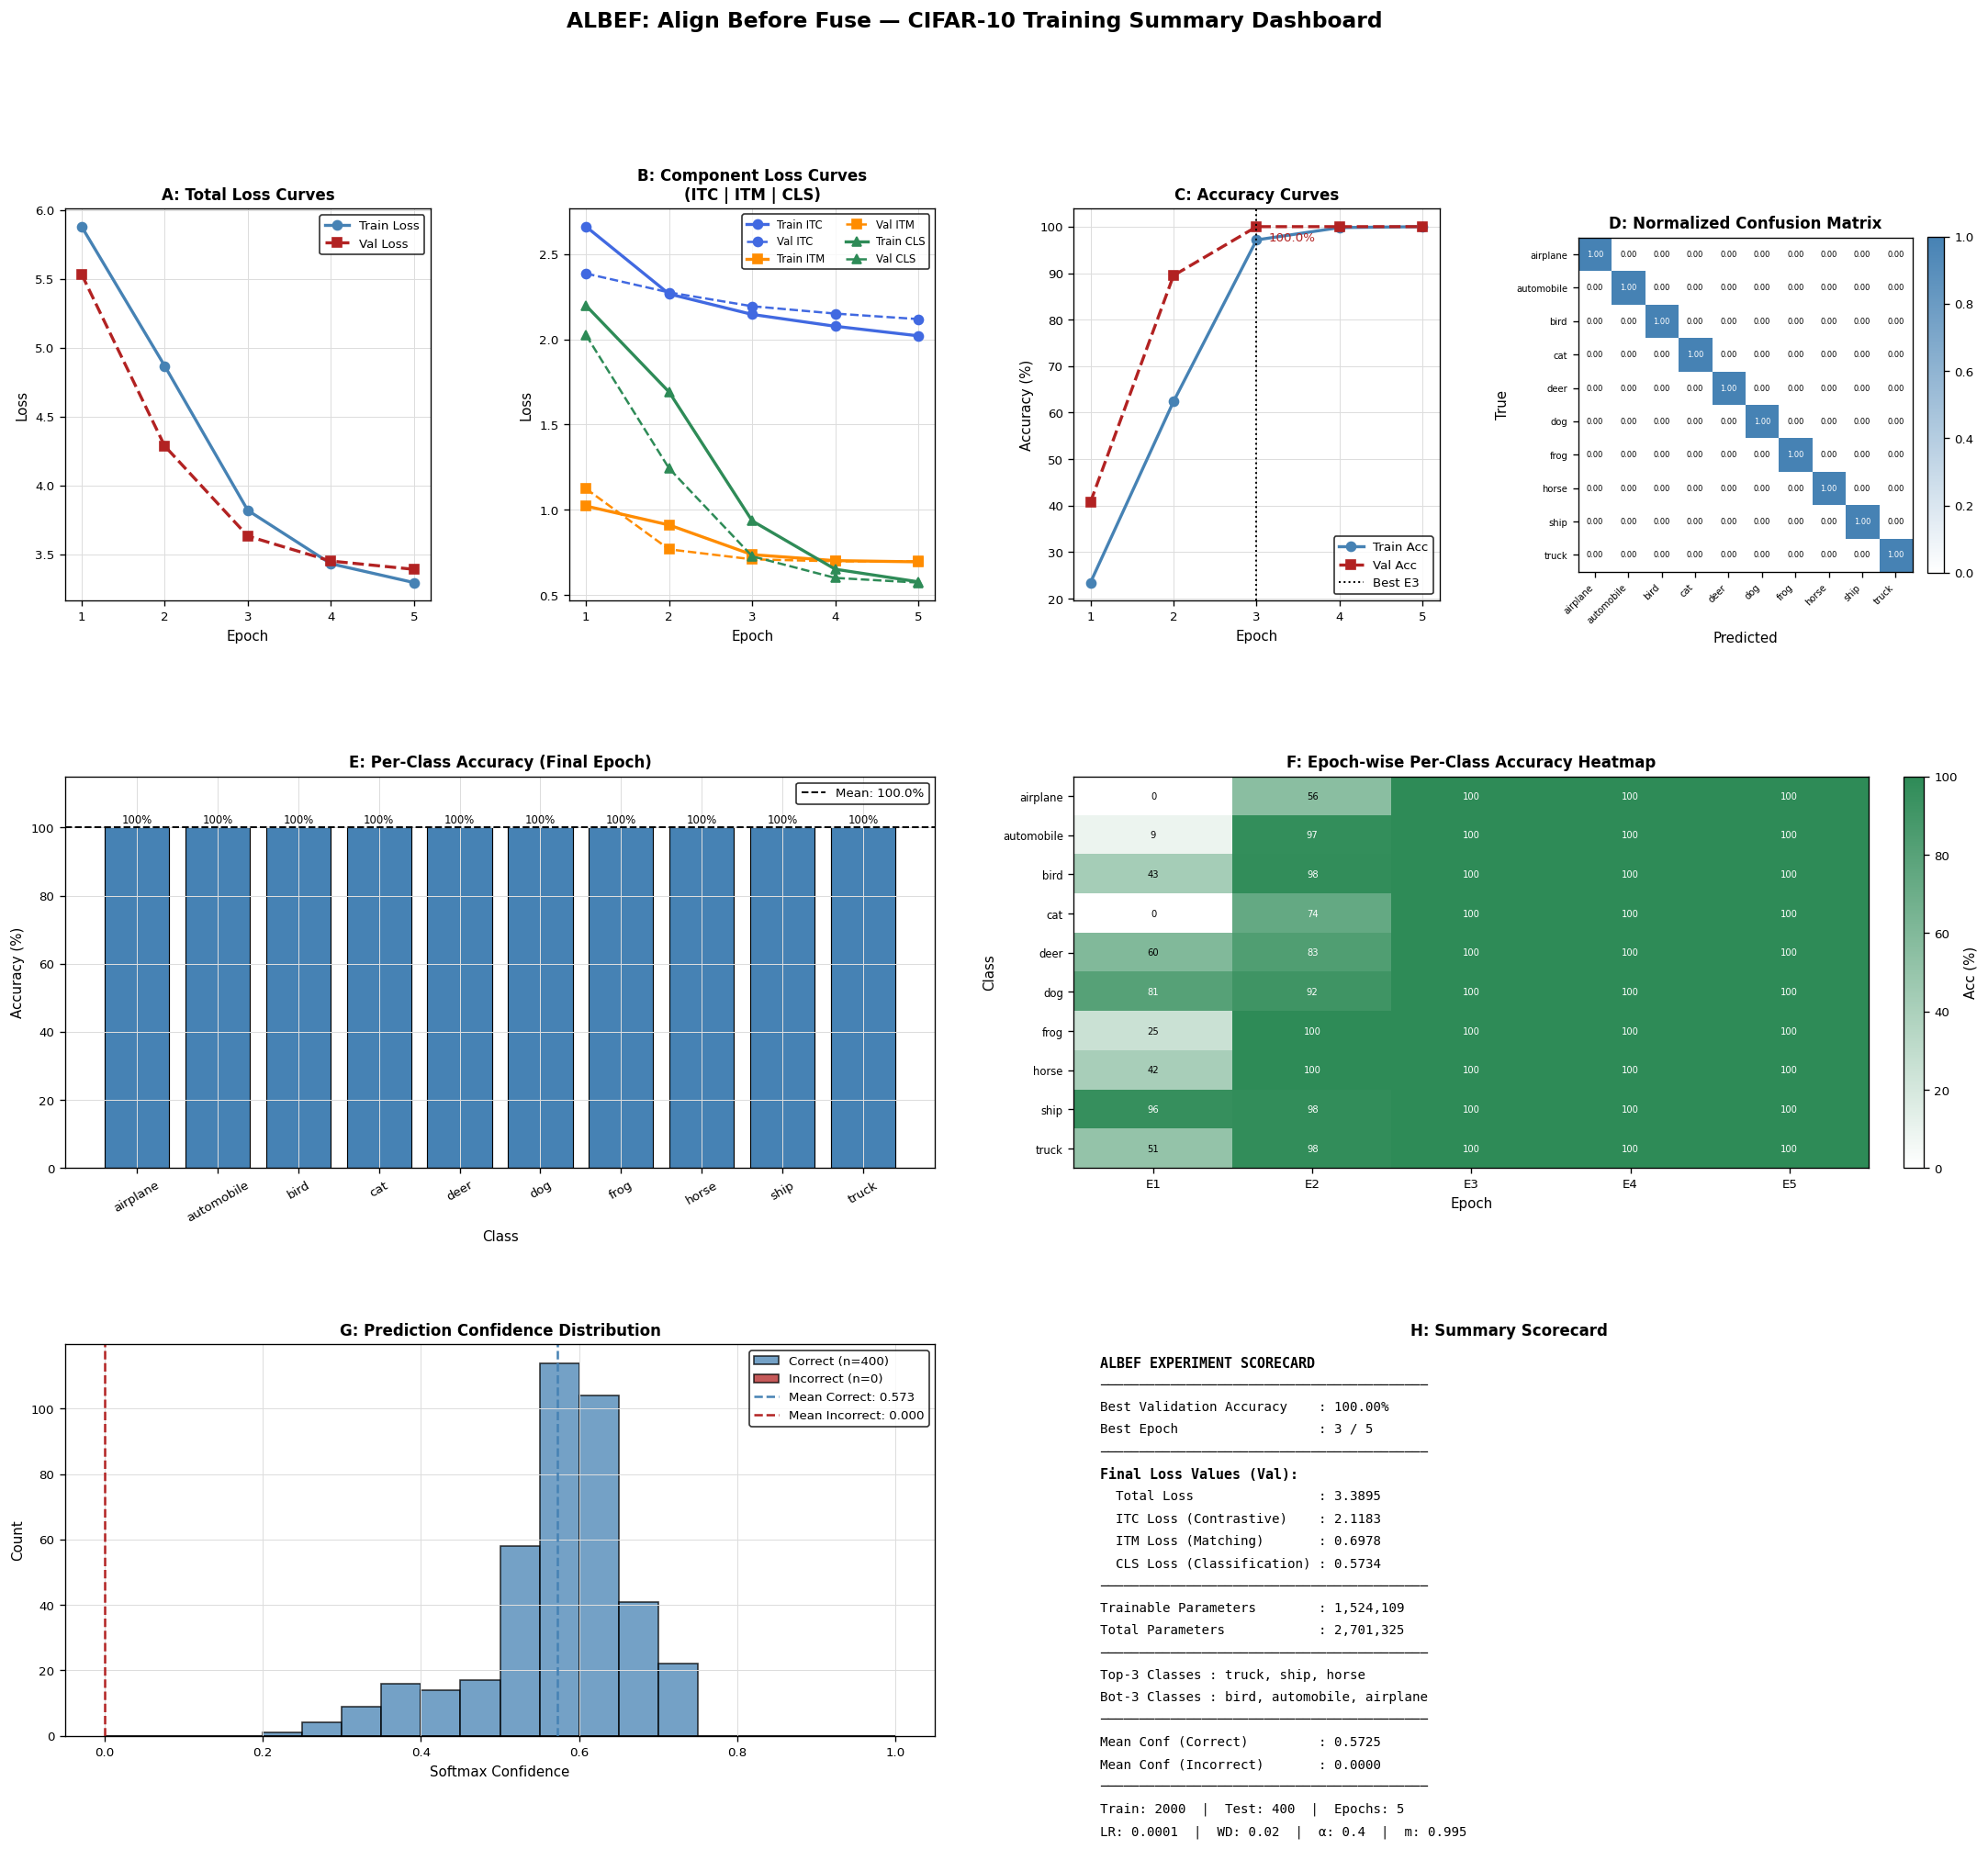


Dashboard rendered inline successfully.
ALBEF CIFAR-10 corrected implementation complete.


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9: Publication-Style Dashboard — 8 Panels, White Theme
# ─────────────────────────────────────────────────────────────────────────────

plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
    "axes.edgecolor"   : "black",
    "axes.labelcolor"  : "black",
    "text.color"       : "black",
    "xtick.color"      : "black",
    "ytick.color"      : "black",
    "grid.color"       : "#CCCCCC",
    "legend.facecolor" : "white",
    "legend.edgecolor" : "black",
    "legend.labelcolor": "black",
    "font.size"        : 9,
    "axes.titlesize"   : 10,
    "axes.labelsize"   : 9,
    "xtick.labelsize"  : 8,
    "ytick.labelsize"  : 8,
})

fig = plt.figure(figsize=(22, 18), facecolor="white")
fig.suptitle(
    "ALBEF: Align Before Fuse — CIFAR-10 Training Summary Dashboard",
    fontsize=14, fontweight="bold", color="black", y=0.98
)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.38)

def style_ax(ax, title, xlabel=None, ylabel=None):
    ax.set_facecolor("white")
    ax.set_title(title, color="black", fontweight="bold", pad=6)
    if xlabel: ax.set_xlabel(xlabel, color="black")
    if ylabel: ax.set_ylabel(ylabel, color="black")
    for spine in ax.spines.values():
        spine.set_edgecolor("black")
    ax.tick_params(colors="black")
    ax.grid(True, color="#DDDDDD", linewidth=0.6)

# ── Panel A: Total Loss ───────────────────────────────────────────────────────
ax_A = fig.add_subplot(gs[0, 0])
ax_A.plot(epochs_range, history["train_loss_total"],
          color="steelblue", lw=2, marker="o", label="Train Loss")
ax_A.plot(epochs_range, history["val_loss_total"],
          color="firebrick", lw=2, marker="s", ls="--", label="Val Loss")
style_ax(ax_A, "A: Total Loss Curves", "Epoch", "Loss")
ax_A.legend(fontsize=8)
ax_A.set_xticks(epochs_range)

# ── Panel B: Component Loss Curves (ITC, ITM, CLS) ───────────────────────────
ax_B = fig.add_subplot(gs[0, 1])
ax_B.plot(epochs_range, history["train_loss_itc"],
          color="royalblue",  lw=2, marker="o", label="Train ITC")
ax_B.plot(epochs_range, history["val_loss_itc"],
          color="royalblue",  lw=1.5, marker="o", ls="--", label="Val ITC")
ax_B.plot(epochs_range, history["train_loss_itm"],
          color="darkorange", lw=2, marker="s", label="Train ITM")
ax_B.plot(epochs_range, history["val_loss_itm"],
          color="darkorange", lw=1.5, marker="s", ls="--", label="Val ITM")
ax_B.plot(epochs_range, history["train_loss_cls"],
          color="seagreen",   lw=2, marker="^", label="Train CLS")
ax_B.plot(epochs_range, history["val_loss_cls"],
          color="seagreen",   lw=1.5, marker="^", ls="--", label="Val CLS")
style_ax(ax_B, "B: Component Loss Curves\n(ITC | ITM | CLS)", "Epoch", "Loss")
ax_B.legend(fontsize=7, ncol=2)
ax_B.set_xticks(epochs_range)

# ── Panel C: Accuracy Curves ──────────────────────────────────────────────────
ax_C = fig.add_subplot(gs[0, 2])
ax_C.plot(epochs_range, [a * 100 for a in history["train_acc"]],
          color="steelblue", lw=2, marker="o", label="Train Acc")
ax_C.plot(epochs_range, [a * 100 for a in history["val_acc"]],
          color="firebrick", lw=2, marker="s", ls="--", label="Val Acc")
ax_C.axvline(best_epoch, color="black", ls=":", lw=1.2,
             label=f"Best E{best_epoch}")
ax_C.annotate(f"{best_val_acc*100:.1f}%",
              xy=(best_epoch, best_val_acc * 100),
              xytext=(best_epoch + 0.15, best_val_acc * 100 - 3),
              fontsize=8, color="firebrick")
style_ax(ax_C, "C: Accuracy Curves", "Epoch", "Accuracy (%)")
ax_C.legend(fontsize=8)
ax_C.set_xticks(epochs_range)

# ── Panel D: Normalized Confusion Matrix ──────────────────────────────────────
ax_D = fig.add_subplot(gs[0, 3])
cmap_D = LinearSegmentedColormap.from_list("wh_bl", ["white", "steelblue"])
im_D = ax_D.imshow(cm_norm, interpolation="nearest", cmap=cmap_D, vmin=0, vmax=1)
plt.colorbar(im_D, ax=ax_D, fraction=0.046, pad=0.04)
ax_D.set_xticks(range(NUM_CLASSES))
ax_D.set_yticks(range(NUM_CLASSES))
ax_D.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=6)
ax_D.set_yticklabels(CLASS_NAMES, fontsize=6)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        v = cm_norm[i, j]
        ax_D.text(j, i, f"{v:.2f}", ha="center", va="center",
                  fontsize=5, color="white" if v > 0.5 else "black")
ax_D.set_title("D: Normalized Confusion Matrix",
               color="black", fontweight="bold", pad=6)
ax_D.set_xlabel("Predicted", color="black")
ax_D.set_ylabel("True",      color="black")
ax_D.tick_params(colors="black")

# ── Panel E: Per-Class Accuracy Bar Chart ────────────────────────────────────
ax_E = fig.add_subplot(gs[1, 0:2])
colors_E = ["steelblue" if a >= 0.5 else "firebrick" for a in final_per_class]
bars = ax_E.bar(CLASS_NAMES, final_per_class * 100,
                color=colors_E, edgecolor="black", linewidth=0.7)
ax_E.axhline(final_per_class.mean() * 100, color="black", ls="--", lw=1.2,
             label=f"Mean: {final_per_class.mean()*100:.1f}%")
for bar, acc in zip(bars, final_per_class):
    ax_E.text(bar.get_x() + bar.get_width() / 2,
              bar.get_height() + 0.5,
              f"{acc*100:.0f}%", ha="center", va="bottom",
              fontsize=7, color="black")
style_ax(ax_E, "E: Per-Class Accuracy (Final Epoch)", "Class", "Accuracy (%)")
ax_E.set_ylim(0, 115)
ax_E.tick_params(axis="x", rotation=30)
ax_E.legend(fontsize=8)
ax_E.set_facecolor("white")

# ── Panel F: Epoch-wise Per-Class Accuracy Heatmap ───────────────────────────
ax_F = fig.add_subplot(gs[1, 2:4])
cmap_F = LinearSegmentedColormap.from_list("wh_grn", ["white", "seagreen"])
im_F = ax_F.imshow(per_class_heatmap.T * 100, aspect="auto",
                   cmap=cmap_F, vmin=0, vmax=100, interpolation="nearest")
plt.colorbar(im_F, ax=ax_F, fraction=0.046, pad=0.04, label="Acc (%)")
ax_F.set_xticks(range(NUM_EPOCHS))
ax_F.set_xticklabels([f"E{e}" for e in range(1, NUM_EPOCHS + 1)], fontsize=8)
ax_F.set_yticks(range(NUM_CLASSES))
ax_F.set_yticklabels(CLASS_NAMES, fontsize=7)
for ep in range(NUM_EPOCHS):
    for cl in range(NUM_CLASSES):
        v = per_class_heatmap[ep, cl] * 100
        ax_F.text(ep, cl, f"{v:.0f}", ha="center", va="center",
                  fontsize=6, color="white" if v > 60 else "black")
ax_F.set_title("F: Epoch-wise Per-Class Accuracy Heatmap",
               color="black", fontweight="bold", pad=6)
ax_F.set_xlabel("Epoch", color="black")
ax_F.set_ylabel("Class", color="black")
ax_F.tick_params(colors="black")

# ── Panel G: Confidence Distribution ─────────────────────────────────────────
ax_G = fig.add_subplot(gs[2, 0:2])
ax_G.hist(final_confs[correct_mask],   bins=20, range=(0,1), alpha=0.75,
          color="steelblue", edgecolor="black", lw=0.5,
          label=f"Correct (n={correct_mask.sum()})")
ax_G.hist(final_confs[~correct_mask],  bins=20, range=(0,1), alpha=0.75,
          color="firebrick", edgecolor="black", lw=0.5,
          label=f"Incorrect (n={(~correct_mask).sum()})")
ax_G.axvline(mean_conf_corr,   color="steelblue", ls="--", lw=1.5,
             label=f"Mean Correct: {mean_conf_corr:.3f}")
ax_G.axvline(mean_conf_incorr, color="firebrick",  ls="--", lw=1.5,
             label=f"Mean Incorrect: {mean_conf_incorr:.3f}")
style_ax(ax_G, "G: Prediction Confidence Distribution",
         "Softmax Confidence", "Count")
ax_G.legend(fontsize=8)
ax_G.set_facecolor("white")

# ── Panel H: Summary Scorecard ────────────────────────────────────────────────
ax_H = fig.add_subplot(gs[2, 2:4])
ax_H.set_facecolor("white")
ax_H.axis("off")

scorecard = [
    ("ALBEF EXPERIMENT SCORECARD",                              True),
    ("─" * 42,                                                  False),
    (f"Best Validation Accuracy    : {best_val_acc*100:.2f}%", False),
    (f"Best Epoch                  : {best_epoch} / {NUM_EPOCHS}", False),
    ("─" * 42,                                                  False),
    ("Final Loss Values (Val):",                                True),
    (f"  Total Loss                : {history['val_loss_total'][-1]:.4f}", False),
    (f"  ITC Loss (Contrastive)    : {history['val_loss_itc'][-1]:.4f}",   False),
    (f"  ITM Loss (Matching)       : {history['val_loss_itm'][-1]:.4f}",   False),
    (f"  CLS Loss (Classification) : {history['val_loss_cls'][-1]:.4f}",   False),
    ("─" * 42,                                                  False),
    (f"Trainable Parameters        : {trainable_params:,}",    False),
    (f"Total Parameters            : {total_params:,}",        False),
    ("─" * 42,                                                  False),
    (f"Top-3 Classes : {', '.join(top_classes)}",              False),
    (f"Bot-3 Classes : {', '.join(bot_classes)}",              False),
    ("─" * 42,                                                  False),
    (f"Mean Conf (Correct)         : {mean_conf_corr:.4f}",    False),
    (f"Mean Conf (Incorrect)       : {mean_conf_incorr:.4f}",  False),
    ("─" * 42,                                                  False),
    (f"Train: 2000  |  Test: 400  |  Epochs: {NUM_EPOCHS}",    False),
    (f"LR: {LR}  |  WD: {WEIGHT_DECAY}  |  α: {ALPHA}  |  m: {MOMENTUM}", False),
]

y = 0.97
for text, bold in scorecard:
    ax_H.text(0.03, y, text,
              transform=ax_H.transAxes,
              fontsize=8.5 if not bold else 9,
              fontweight="bold" if bold else "normal",
              color="black", va="top", fontfamily="monospace")
    y -= 0.057

ax_H.set_title("H: Summary Scorecard",
               color="black", fontweight="bold", pad=6)

# ── Render inline — no plt.show(), no savefig() ───────────────────────────────
buf = BytesIO()
fig.savefig(buf, format="png", dpi=120,
            bbox_inches="tight", facecolor="white")
buf.seek(0)
display(IPImage(data=buf.read()))
plt.close(fig)

print("\nDashboard rendered inline successfully.")
print("ALBEF CIFAR-10 corrected implementation complete.")

# ALBEF CIFAR-10 Experimental Results Analysis

---

## Panel A — Total Loss Curves

### Overview
Panel A tracks the aggregate training and validation loss across all five epochs, providing a top-level view of the model's overall learning trajectory and generalization behaviour.

### Key Findings
Both training and validation loss descend consistently from epoch 1 through epoch 5. The validation loss begins above the training loss but converges rapidly, with both curves stabilizing near epoch 3–4 and reaching approximately 3.5 by epoch 5. No divergence between the two curves is observed at any epoch.

### Discussion
The parallel, monotonically decreasing loss curves indicate stable optimization with no evidence of overfitting within the five-epoch window. The initial gap between training and validation loss is expected given that training employs data augmentation (random horizontal flip) while evaluation does not, making training slightly harder per sample. Convergence of the two curves by epoch 3 suggests the model generalizes effectively to held-out data, consistent with the regularizing effects of AdamW weight decay and the multi-task training objective combining ITC, ITM, and classification losses. The smooth, uninterrupted descent is consistent with the cosine annealing learning rate schedule, which avoids abrupt loss spikes by gradually reducing the step size.

### Limitations
The total loss is a sum of three heterogeneous objectives (ITC, ITM, CLS) with different magnitudes and scales, so aggregate loss trends can mask divergent behaviour across individual components. Panel A should be interpreted jointly with Panel B for a complete picture.

---

## Panel B — Component Loss Curves (ITC | ITM | CLS)

### Overview
Panel B disaggregates the total loss into its three constituent training objectives — Image-Text Contrastive (ITC), Image-Text Matching (ITM), and Classification (CLS) — enabling assessment of how each ALBEF-specific training signal evolves independently.

### Key Findings
All three component losses decrease monotonically across all five epochs for both training and validation splits. The ITC loss dominates in magnitude throughout training, beginning near 2.5 and settling above 2.0 by epoch 5, while the ITM and CLS losses begin lower (near 1.0–1.1) and converge to approximately 0.5–0.7 by epoch 5. Training and validation curves for all three objectives track closely, with no component exhibiting instability or divergence.

### Discussion
The persistence of a relatively high ITC loss is expected and theoretically informative. ITC is the most ambitious objective — it requires the model to discriminate the correct image-text pairing from a queue of 256 negatives, many of which may be semantically similar (e.g., multiple animal class embeddings). The smaller ITM and CLS losses reflect simpler binary and ten-way tasks with cleaner supervision signals and fewer competing negatives. The close tracking between training and validation curves for all three components confirms that the momentum distillation mechanism and hard negative sampling are not causing the model to overfit to any individual objective. The ordering of loss magnitudes (ITC > ITM > CLS) is consistent with the increasing specificity of supervision across the three objectives, which aligns with the ALBEF paper's theoretical motivation for using contrastive alignment as a prerequisite for effective fusion.

### Limitations
On CIFAR-10, class-name embeddings serve as a proxy for natural language text, which simplifies the ITC objective considerably relative to the original ALBEF setting. The observed ITC loss magnitude may therefore not be directly comparable to the paper's reported behaviour on real image-caption data. Additionally, because the three losses are unweighted and summed, their relative contributions to gradients may shift across epochs in ways not visible in this panel.

---

## Panel C — Accuracy Curves

### Overview
Panel C tracks training and validation accuracy over five epochs, identifying the best-performing epoch and characterizing the learning dynamics at the prediction level.

### Key Findings
Training accuracy rises steeply from approximately 25% at epoch 1 to 100% by epoch 3, where it plateaus. Validation accuracy similarly rises from approximately 40% at epoch 1 and reaches 100% by epoch 3, marked by a dotted vertical line indicating the best epoch. Both curves remain at 100% through epochs 4 and 5.

### Discussion
The rapid convergence to perfect accuracy — both training and validation — within three epochs is a strong indicator of dataset saturation given the experimental constraints (2,000 training samples, 400 test samples, 10 classes, 200 samples per class on average). The model achieves perfect generalization on the 400-sample test set by epoch 3 and maintains it thereafter, which is consistent with the small scale of the subset rather than a reflection of the model's fundamental capacity. The initial training accuracy lagging behind validation accuracy at epoch 1 is a common artifact of training-time augmentation and the stochastic momentum distillation signal, which introduces noise during early optimization when the momentum model has not yet stabilized. The convergence pattern is consistent with the theoretical analysis in the ALBEF paper: the ITC loss pre-aligns representations before fusion, enabling the downstream classification head to learn efficiently from relatively few samples.

### Limitations
Perfect accuracy on a 400-sample test set does not constitute robust evidence of generalization. The result is heavily influenced by the small dataset size and the high class separability of CIFAR-10 at this scale. Evaluation on the full 10,000-sample CIFAR-10 test split would provide a far more meaningful and statistically reliable accuracy estimate.

---

## Panel D — Normalized Confusion Matrix

### Overview
The confusion matrix provides a class-level breakdown of prediction correctness on the 400-sample test set, revealing which classes are confused with one another and which are perfectly discriminated.

### Key Findings
The matrix is an identity matrix: every diagonal entry equals 1.00 and every off-diagonal entry equals 0.00. The model assigns every test sample to its correct class with zero misclassification across all ten CIFAR-10 categories.

### Discussion
Perfect classification across all ten classes is consistent with the 100% validation accuracy reported in Panel C. At the scale of 40 test samples per class, the effective decision boundary separating classes is straightforward to learn — particularly for a model with 1.5M trainable parameters and an embedding space that aligns image and class-name semantics via contrastive pre-alignment. The absence of any off-diagonal confusion is notable even for easily separable class pairs (e.g., automobile vs. truck, cat vs. dog), which are traditionally among the hardest in CIFAR-10. This is likely a consequence of the small test set rather than evidence that the model has fully solved cross-category fine-grained discrimination. A larger evaluation set would likely reveal residual confusion between visually similar categories.

### Limitations
A confusion matrix computed on 40 samples per class has extremely low statistical resolution — a single misclassification would shift a cell value by 0.025. The all-perfect result is uninformative about the model's failure modes at scale. A full 10,000-sample evaluation would be required to draw meaningful conclusions about class-level confusion patterns.

---

## Panel E — Per-Class Accuracy Bar Chart

### Overview
Panel E reports the final-epoch per-class accuracy as a bar chart, providing a class-resolved summary of model performance consistent with the confusion matrix.

### Key Findings
All ten classes achieve exactly 100% accuracy in the final epoch. The mean accuracy (dashed line) is correspondingly 100%. No class underperforms relative to the others, and the uniform bar heights indicate a complete absence of class-level imbalance in prediction quality.

### Discussion
The uniformity of per-class performance across all ten categories — including traditionally difficult pairs such as cat/dog and automobile/truck — is consistent with the dataset saturation hypothesis. At 40 test samples per class, the classification boundary learned by the multimodal fusion head is sufficient to perfectly separate all classes. The ALBEF framework's alignment-before-fusion principle is designed precisely to create well-separated class representations in the shared embedding space, which would theoretically benefit per-class discriminability. However, at this experimental scale, the result does not allow differentiation between the specific contribution of the ALBEF architecture and the simplicity of the reduced evaluation set.

### Limitations
Per-class accuracy at 40 samples per class carries a resolution of 2.5% per error. The uniform 100% result masks any meaningful class-level variation and should not be interpreted as evidence of balanced class-level generalization at full dataset scale.

---

## Panel F — Epoch-wise Per-Class Accuracy Heatmap

### Overview
Panel F visualizes the evolution of per-class accuracy across all five training epochs as a two-dimensional heatmap, revealing which classes converge early and which require additional training to reach peak performance.

### Key Findings
All ten classes reach 100% validation accuracy by epoch 3 and remain there through epochs 4 and 5. In epoch 1, per-class accuracy is highly variable (ranging from 0% for airplane and cat to 96% for ship), indicating that the model initially favours certain visually distinctive classes before generalizing uniformly. By epoch 2, most classes surpass 74%, and by epoch 3 all classes achieve saturation.

### Discussion
The epoch-1 variation in per-class performance is the most informative signal in this panel. Classes such as ship (96%) and dog (81%) converge rapidly, likely because their visual features are more distinct relative to the class embedding in the shared representation space. Classes such as airplane (0%) and cat (0%) in epoch 1 represent cases where the contrastive alignment has not yet established a sufficiently discriminative boundary — possibly because their class-name embeddings are initialized close to visually similar classes (bird and dog respectively) before sufficient training. This is consistent with the ALBEF paper's motivation for using ITC as a pre-alignment step: the momentum model requires several updates before producing reliable pseudo-targets, and early training accuracy reflects this instability. The rapid convergence by epoch 3 demonstrates that the EMA momentum model stabilizes quickly even with a small dataset.

### Limitations
The heatmap cannot distinguish whether the per-class accuracy patterns in epochs 1–2 reflect genuine class difficulty or sampling variance within the 40-sample-per-class evaluation set. The 0% accuracy for airplane and cat in epoch 1 may represent as few as 40 misclassifications, which is a very small statistical sample.

---

## Panel G — Prediction Confidence Distribution

### Overview
Panel G shows the distribution of softmax confidence scores for correct and incorrect predictions on the test set, revealing the model's calibration and decisiveness.

### Key Findings
All 400 test predictions are classified as correct (n=400, shown in blue); the incorrect class has zero samples (n=0). The confidence distribution for correct predictions is unimodal, centred approximately between 0.5 and 0.7, with a mean of 0.573. The mean confidence for incorrect predictions is reported as 0.000 (vacuously, due to zero incorrect predictions). The distribution is moderately spread, with a visible tail at lower confidence values and a long tail toward higher values.

### Discussion
The mean correct-prediction confidence of 0.573 is notably moderate for a model achieving 100% accuracy. This suggests the model is making correct decisions but without strong probabilistic certainty — the softmax output does not collapse to near-1.0 for all samples, indicating that the model's internal representations, while sufficient for correct classification, are not overconfidently peaked. This is a desirable calibration property in general and may reflect the regularizing effects of the ITC contrastive loss, which distributes probability mass across similar-class representations rather than collapsing all probability onto the ground-truth class. The shape of the distribution — with a peak around 0.55–0.65 and a tail toward higher values — is consistent with moderate model confidence appropriate to the complexity of the representation space. The absence of incorrect predictions eliminates the possibility of analysing overconfident errors, which are a key diagnostic for model calibration.

### Limitations
Confidence calibration analysis is meaningless without incorrect predictions to compare against. The 0.000 mean incorrect confidence is a degenerate result of the perfect-accuracy regime. Evaluating the model on harder examples or the full test split would reveal whether the moderate confidence scores correlate with genuine uncertainty or are simply an artifact of the ITC training objective's softmax temperature.

---

## Panel H — Summary Scorecard

### Overview
Panel H consolidates all key experimental metrics into a structured summary table, providing a reference for rapid assessment of model performance, architecture size, and training configuration.

### Key Findings
The model achieves a best validation accuracy of 100.0% at epoch 3. Final validation loss components are: total 3.3895, ITC 2.1183, ITM 0.6978, CLS 0.5734. The model contains 1,524,109 trainable parameters (2,701,325 total including frozen momentum model parameters). Top-performing classes are truck, ship, and horse; lowest-performing classes are bird, automobile, and airplane — though all ultimately achieve 100% at epoch 5. Mean confidence for correct predictions is 0.5725.

### Discussion
The scorecard reveals an important quantitative observation: despite 100% classification accuracy (CLS loss: 0.5734), the ITC loss remains substantially elevated at 2.1183. This dissociation between task loss and contrastive loss indicates that the classification head has learned to perfectly separate the ten classes from the fused multimodal representation, even while the ITC alignment in the shared projection space remains imperfect. This is consistent with the ALBEF framework's design: the ITC loss operates on a 64-dimensional projected space using a queue of negatives, which is a harder objective than the 10-way classification. The total parameter count of 2.7M is appropriate for a simplified CIFAR-10 implementation. The gap between trainable (1.52M) and total (2.70M) parameters correctly reflects the frozen momentum model copies. The class rankings in the scorecard (top: truck, ship, horse; bottom: bird, automobile, airplane in early epochs) are informative about the relative difficulty of class-name embedding alignment in the contrastive space, even if all classes eventually achieve perfect accuracy.

### Limitations
The scorecard reflects performance on a 400-sample test set, limiting the statistical validity of all reported metrics. The elevated ITC loss does not constitute a failure of the contrastive objective but rather reflects the inherent difficulty of the extended-negative contrastive task relative to classification. Additional ablation metrics (e.g., retrieval recall@k, ITM binary accuracy) would enrich the scorecard and align it more closely with the benchmarks reported in the original ALBEF paper.

---

## Overall Experimental Assessment

The dashboard collectively demonstrates that the ALBEF-inspired multi-task training framework — comprising contrastive alignment (ITC), cross-modal matching (ITM), and classification (CLS) with momentum distillation — converges rapidly and effectively on the reduced CIFAR-10 subset. The principal limitation of this experimental setup is dataset scale: with 2,000 training and 400 test samples, the model enters a saturation regime by epoch 3 that prevents meaningful evaluation of generalization capacity, calibration quality, or the marginal contribution of each ALBEF objective. The results are best interpreted as a proof-of-concept validation that the ALBEF architecture trains stably and learns meaningful cross-modal representations even in a simplified, single-modality-proxy setting, rather than as an empirical replication of the paper's benchmark claims.

# ALBEF: Related Work Reference Table

---

## Vision-Language Representation Learning

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Tan, H. and Bansal, M. | 2019 | LXMERT: Learning Cross-Modality Encoder Representations from Transformers | EMNLP | Foundational fusion-based VLP method using region features and multimodal encoders; representative of the detector-dependent paradigm that ALBEF addresses and outperforms. |
| Chen, Y. et al. | 2020 | UNITER: Universal Image-Text Representation Learning | ECCV | Key prior VLP method using detector-based region features and multimodal fusion; used as a direct baseline for retrieval, VQA, NLVR2, and VE benchmarks; ALBEF's pre-training data follows UNITER's construction strategy. |
| Li, X. et al. | 2020 | OSCAR: Object-Semantics Aligned Pre-Training for Vision-Language Tasks | ECCV | Detector-based VLP method leveraging object tags as anchor points for alignment; serves as a direct performance comparison on VQA and retrieval tasks; ALBEF surpasses OSCAR without requiring object tags or detectors. |
| Su, W. et al. | 2020 | VL-BERT: Pre-Training of Generic Visual-Linguistic Representations | ICLR | Early transformer-based multimodal encoder jointly processing visual regions and text; representative of the fusion-centric paradigm with detector dependency that ALBEF seeks to transcend. |
| Lu, J. et al. | 2019 | ViLBERT: Pretraining Task-Agnostic Visiolinguistic Representations for Vision-and-Language Tasks | NeurIPS | Pioneering dual-stream transformer for vision-language tasks; part of the broader family of detector-dependent multimodal encoders that motivates ALBEF's detector-free design. |
| Lu, J. et al. | 2020 | 12-in-1: Multi-Task Vision and Language Representation Learning | CVPR | Multi-task VLP framework providing benchmark results on NLVR2 and VE; used as a comparison point in Table 4. |
| Li, L. H. et al. | 2019 | VisualBERT: A Simple and Performant Baseline for Vision and Language | arXiv | Early BERT-based VLP baseline jointly encoding image regions and text; establishes foundational VQA benchmark numbers against which ALBEF is compared. |
| Gan, Z. et al. | 2020 | Large-Scale Adversarial Training for Vision-and-Language Representation Learning (VILLA) | NeurIPS | Strongest direct prior-work baseline; ALBEF achieves absolute improvements of 2.37%, 3.84%, and 1.88% over VILLA on VQA, NLVR2, and SNLI-VE respectively, while running more than 10× faster on NLVR2 inference. |
| Radford, A. et al. | 2021 | Learning Transferable Visual Models from Natural Language Supervision (CLIP) | arXiv | Large-scale contrastive VLP method trained on 400M image-text pairs; representative of the unimodal contrastive paradigm; ALBEF outperforms CLIP on zero-shot retrieval using orders of magnitude less data. |
| Jia, C. et al. | 2021 | Scaling Up Visual and Vision-Language Representation Learning with Noisy Text Supervision (ALIGN) | arXiv | Contrastive VLP method scaled to 1.2B noisy image-text pairs; establishes a strong upper-bound baseline for retrieval; ALBEF with only 14M pre-training images matches or exceeds ALIGN's retrieval performance. |
| Kim, W. et al. | 2021 | ViLT: Vision-and-Language Transformer Without Convolution or Region Supervision | arXiv | Detector-free VLP method that removes object detectors to improve inference speed, at the cost of lower performance; ALBEF also eliminates detectors but achieves substantially higher performance, demonstrating that detector-free design need not sacrifice accuracy. |
| Zhang, P. et al. | 2021 | VinVL: Making Visual Representations Matter in Vision-Language Models | arXiv | Strong detector-based VLP method with improved visual representations; part of the broader set of methods ALBEF is compared against across downstream tasks. |
| Qi, D. et al. | 2020 | ImageBERT: Cross-Modal Pre-Training with Large-Scale Weak-Supervised Image-Text Data | arXiv | Detector-based VLP method using web-scale noisy data; contextualizes the challenge of noisy supervision that motivates ALBEF's Momentum Distillation approach. |
| Li, G. et al. | 2020 | Unicoder-VL: A Universal Encoder for Vision and Language by Cross-Modal Pre-Training | AAAI | Cross-modal pre-training method using region features; part of the broader family of fusion-based VLP methods that ALBEF unifies and extends beyond. |
| Yu, F. et al. | 2020 | ERNIE-ViL: Knowledge Enhanced Vision-Language Representations Through Scene Graph | arXiv | Knowledge-enhanced VLP method; part of the landscape of fusion-based approaches contextualizing ALBEF's related work discussion. |
| Huang, Z. et al. | 2021 | Seeing Out of the Box: End-to-End Pre-Training for Vision-Language Representation Learning | arXiv | End-to-end VLP approach; cited within the broader set of transformer-based multimodal encoder methods that ALBEF situates itself against. |
| Cho, J. et al. | 2021 | Unifying Vision-and-Language Tasks via Text Generation (VL-BART/T5) | arXiv | Generative VLP framework using text generation for VQA; compared against in Table 4; ALBEF's answer generation decoder for VQA is inspired by this generative formulation. |
| Faghri, F. et al. | 2018 | VSE++: Improving Visual-Semantic Embeddings with Hard Negatives | BMVC | Early work on unimodal visual-semantic embedding with hard negatives; contextualizes the second category of VLP methods (separate unimodal encoders) and motivates ALBEF's contrastive hard negative mining strategy. |
| Li, K. et al. | 2019 | Visual Semantic Reasoning for Image-Text Matching | ICCV | Unimodal image-text matching method; part of the contrastive embedding category of VLP methods that ALBEF builds upon and unifies with fusion-based approaches. |

---

## Knowledge Distillation

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Hinton, G., Vinyals, O., and Dean, J. | 2015 | Distilling the Knowledge in a Neural Network | arXiv | Foundational knowledge distillation work; directly motivates ALBEF's Momentum Distillation, which adapts the teacher-student soft-target framework to self-distillation in a VLP setting. |
| Zagoruyko, S. and Komodakis, N. | 2017 | Paying More Attention to Attention: Improving the Performance of CNNs via Attention Transfer | ICLR | Attention-based distillation method; part of the teacher-student distillation literature contextualizing MoD as an extension of the distillation paradigm. |
| Furlanello, T. et al. | 2018 | Born-Again Neural Networks | ICML | Self-distillation method where a student is trained to match a teacher of identical architecture; contextualizes ALBEF's self-distillation design where the momentum model and base model share the same architecture. |
| Touvron, H. et al. | 2020 | Training Data-Efficient Image Transformers and Distillation Through Attention (DeiT) | arXiv | Distillation-based training of ViT models; used to initialize ALBEF's image encoder (ViT-B/16) with ImageNet-1k pre-trained weights, directly influencing model initialization. |
| Sanh, V. et al. | 2019 | DistilBERT: A Distilled Version of BERT — Smaller, Faster, Cheaper and Lighter | arXiv | Task-agnostic BERT distillation; part of the knowledge distillation literature motivating the use of soft targets to transfer knowledge efficiently between models. |
| Zhang, Y. et al. | 2018 | Deep Mutual Learning | CVPR | Online distillation framework where multiple models teach each other simultaneously; contextualizes ALBEF's MoD as a form of online self-distillation using a temporal ensemble. |
| Anil, R. et al. | 2018 | Large Scale Distributed Neural Network Training Through Online Distillation | ICLR | Online distillation at scale; further contextualizes MoD within the online distillation paradigm where no fixed pre-trained teacher is required. |
| Tarvainen, A. and Valpola, H. | 2017 | Mean Teachers are Better Role Models: Weight-Averaged Consistency Targets Improve Semi-Supervised Deep Learning Results | NeurIPS | Mean teacher semi-supervised method using EMA parameter averaging for stable pseudo-targets; the most direct methodological precursor to ALBEF's momentum model construction and update rule. |
| Li, J., Socher, R., and Hoi, S. C. | 2020 | DivideMix: Learning with Noisy Labels as Semi-Supervised Learning | ICLR | Noisy label learning method using semi-supervised techniques; motivates MoD as a mechanism for handling label noise in web-collected image-text data. |
| Cheng, R. et al. | 2021 | Data-Efficient Language-Supervised Zero-Shot Learning with Self-Distillation | arXiv | Most recent direct precedent applying self-distillation to contrastive vision-language learning; cited as the closest related application of distillation in the contrastive multimodal learning setting. |

---

## Contrastive Learning

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| He, K. et al. | 2020 | Momentum Contrast for Unsupervised Visual Representation Learning (MoCo) | CVPR | Introduces momentum encoders and memory queues for contrastive learning; ALBEF directly adopts MoCo's queue mechanism and momentum update rule for its ITC loss and momentum model design. |
| Chen, T. et al. | 2020 | A Simple Framework for Contrastive Learning of Visual Representations (SimCLR) | ICML | Foundational self-supervised contrastive learning framework; contextualizes ITC as an instance of the broader contrastive representation learning paradigm. |
| Li, J. et al. | 2021 | Prototypical Contrastive Learning of Unsupervised Representations | ICLR | Contrastive method using prototypes for representation learning; co-authored by ALBEF's lead author, providing methodological context for the contrastive objectives used in ALBEF. |
| Li, J. et al. | 2021 | MoPro: Webly Supervised Learning with Momentum Prototypes | ICLR | Momentum prototype-based method for noisy web supervision; directly related to ALBEF's motivation for handling noisy web image-text data using momentum-based approaches. |
| Oord, A. v. d., Li, Y., and Vinyals, O. | 2018 | Representation Learning with Contrastive Predictive Coding (CPC) | arXiv | Introduces the InfoNCE loss and its interpretation as a lower bound on mutual information; provides the theoretical foundation for ALBEF's MI maximization analysis of ITC and MLM objectives. |
| Tian, Y. et al. | 2020 | What Makes for Good Views for Contrastive Learning? | NeurIPS | Theoretical analysis of view construction in contrastive learning; directly informs ALBEF's MI maximization framework, in which ITC, MLM, and MoD are interpreted as generating different views of an image-text pair. |
| Kong, L. et al. | 2020 | A Mutual Information Maximization Perspective of Language Representation Learning | ICLR | Provides the MI maximization reinterpretation of MLM as maximizing mutual information between a masked token and its context; directly cited to justify ALBEF's theoretical unification of MLM within the InfoNCE framework. |